In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

from config import *


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


c:\Users\Rawan\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\Users\Rawan\Desktop\GSoC26\config.py:118: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
df = pd.read_csv(r"dataframes/df_soil_moisture.csv", parse_dates=[0], index_col=0)

# features = ['temperature_2m', 'total_evaporation']
# input_size = 2

features = ["temperature_2m", "dewpoint_temperature_2m", 
              "skin_temperature", "surface_net_thermal_radiation_sum"]
input_size = len(features)

features = ["temperature_2m", "dewpoint_temperature_2m", 
            "skin_temperature", "surface_net_thermal_radiation_sum"]

input_size = len(features)

data = df[features].iloc[:-30*5]
test = df[features].iloc[-30*5:]

test_index = test.index
train_index = data.index

In [ ]:
# Prepare sequences for LSTM
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length, 0]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


# LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

 
# initialize model, loss, optimizer
model = LSTMModel(input_size=input_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [4]:
# scale data (important for LSTM)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
X, y = create_sequences(data_scaled, SEQ_LENGTH)
print(X.shape)   # should be (samples, seq_length, 4)
# convert to PyTorch tensors
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float().unsqueeze(1)


# train model
for epoch in range(EPOCHS):
    model.train()
    outputs = model(X)
    optimizer.zero_grad()
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    
    print(f'Epoch {epoch+1}, Loss: {loss.item():.3f}')

# predict next n steps
model.eval()
preds = []

# start with last sequence in data
preds = []
last_seq = X[-1].unsqueeze(0)  # shape (1, seq_length, 1)
for _ in range(future_steps):
    with torch.no_grad():
        next_val = model(last_seq)
        preds.append(next_val.item())
        # append predicted value to sequence
        # last_seq = torch.cat((last_seq[:,1:,:], next_val.unsqueeze(1)), dim=1)
        new_step = torch.cat((next_val.unsqueeze(-1), last_seq[:, -1:, 1:]), dim=-1)
        last_seq = torch.cat((last_seq[:, 1:, :], new_step), dim=1)
            
# # Inverse scale
# preds_rescaled = scaler.inverse_transform(np.array(preds).reshape(-1,1))
# print("Next", future_steps, "hour predictions:")
# print(preds_rescaled)

preds_array = np.array(preds).reshape(-1,1)
dummy = np.zeros((preds_array.shape[0], input_size - 1))
preds_full = np.hstack((preds_array, dummy))
preds_rescaled = scaler.inverse_transform(preds_full)[:, 0]

(143, 150, 4)
Epoch 1, Loss: 0.731
Epoch 2, Loss: 0.407
Epoch 3, Loss: 0.118
Epoch 4, Loss: 0.081
Epoch 5, Loss: 0.037
Epoch 6, Loss: 0.005
Epoch 7, Loss: 0.020
Epoch 8, Loss: 0.031
Epoch 9, Loss: 0.028
Epoch 10, Loss: 0.017
Epoch 11, Loss: 0.008
Epoch 12, Loss: 0.006
Epoch 13, Loss: 0.011
Epoch 14, Loss: 0.016
Epoch 15, Loss: 0.016
Epoch 16, Loss: 0.012
Epoch 17, Loss: 0.008
Epoch 18, Loss: 0.006
Epoch 19, Loss: 0.006
Epoch 20, Loss: 0.008
Epoch 21, Loss: 0.010
Epoch 22, Loss: 0.010
Epoch 23, Loss: 0.009
Epoch 24, Loss: 0.008
Epoch 25, Loss: 0.006
Epoch 26, Loss: 0.006
Epoch 27, Loss: 0.006
Epoch 28, Loss: 0.007
Epoch 29, Loss: 0.008
Epoch 30, Loss: 0.008
Epoch 31, Loss: 0.007
Epoch 32, Loss: 0.006
Epoch 33, Loss: 0.006
Epoch 34, Loss: 0.006
Epoch 35, Loss: 0.006
Epoch 36, Loss: 0.006
Epoch 37, Loss: 0.006
Epoch 38, Loss: 0.006
Epoch 39, Loss: 0.006
Epoch 40, Loss: 0.005
Epoch 41, Loss: 0.005
Epoch 42, Loss: 0.005
Epoch 43, Loss: 0.005
Epoch 44, Loss: 0.006
Epoch 45, Loss: 0.005
Epoch

In [5]:
# # Make sure test has timestamps
# # If you already predicted 200 points (from LSTM on last 200 sequences)
# # Convert preds_rescaled to pandas Series
forecast_series = pd.Series(preds_rescaled.flatten(), index=test_index)

# plt.figure(figsize=(12,6))

# # Plot real data
# plt.plot(test_index, test['temperature_2m'], label='Observed', color='blue')

# # Plot forecast
# plt.plot(forecast_series.index, forecast_series.values, label='Forecast', color='red', linestyle='--')

# plt.xlabel('Time')
# plt.ylabel('Temperature at 2m')
# plt.title('Observed vs Forecasted Temperature')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

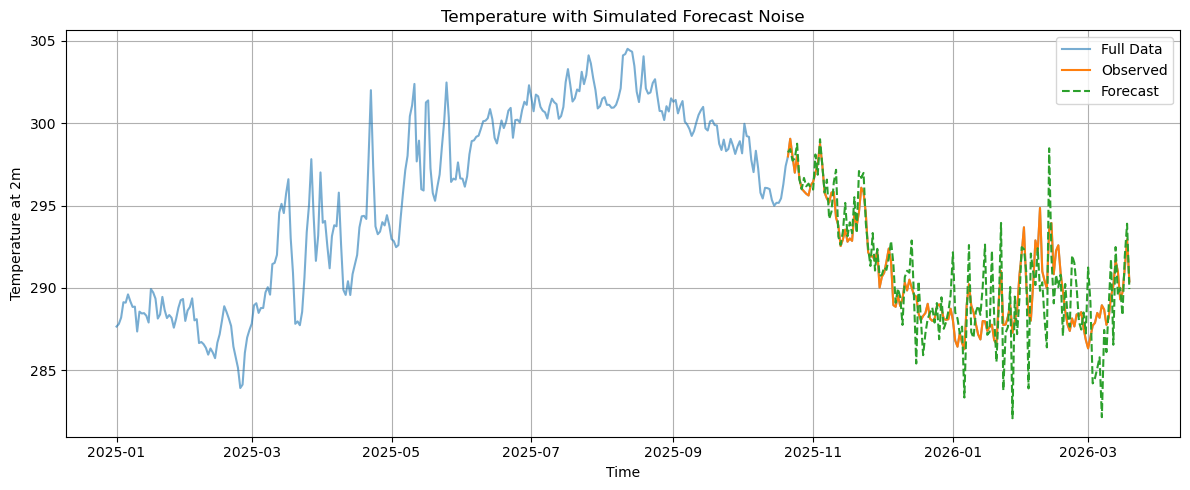

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["temperature_2m"], alpha=0.6, label="Full Data")
plt.plot(test.index, test["temperature_2m"], label="Observed")
plt.plot(forecast_series.index, forecast_series.values,
         "--", label="Forecast")

plt.title("Temperature with Simulated Forecast Noise")
plt.xlabel("Time")
plt.ylabel("Temperature at 2m")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
